# 04 · Compare all models and pick the winner

Reads every result in `Output/results/` (from notebooks 02 and 03), ranks them on the same test set, and picks the best model.

**Selection rule:** highest macro-F1. If two models are within 0.01 macro-F1, prefer the one with higher neutral recall (the hardest class), then the smaller/faster one.

In [8]:
from pathlib import Path
# Works whether the notebook runs from the Notebooks folder (VS Code default) or the project root
ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
DATA, OUTPUT = ROOT / 'Data', ROOT / 'Output'
RESULTS = OUTPUT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)

import json
import pandas as pd, matplotlib.pyplot as plt

LABELS = ['not satisfied', 'neutral', 'satisfied']
res = pd.DataFrame([json.load(open(p)) for p in sorted(RESULTS.glob('*.json'))])
if 'preset' in res:
    partial = res[res['preset'].notna() & (res['preset'] != 'full')]
    if len(partial):
        print('Note: these transformers were trained with a reduced preset, so they likely underestimate the full run:',
              ', '.join(f"{m} ({p})" for m, p in zip(partial.model, partial.preset)))
cols = ['family'] + [c for c in ['preset', 'input'] if c in res] + ['macro_f1'] + (['macro_f1_untuned'] if 'macro_f1_untuned' in res else []) + [ 'accuracy', 'recall_not satisfied', 'recall_neutral', 'recall_satisfied', 'f1_neutral']
table = res.set_index('model')[cols].sort_values('macro_f1', ascending=False)
table.round(3)

Note: these transformers were trained with a reduced preset, so they likely underestimate the full run: bert_base_lite (lite), deberta_v3_base_lite (lite), deberta_v3_base_medium (medium), deberta_v3_base_medium_2ep (medium_2ep), distilbert_lite (lite), roberta_base_lite (lite), twitter_roberta_sentiment_lite (lite), twitter_roberta_sentiment_medium (medium)


,family,preset,input,macro_f1,macro_f1_untuned,accuracy,recall_not satisfied,recall_neutral,recall_satisfied,f1_neutral
model,,,,,,,,,,
deberta_v3_base_medium,transformer,medium,title+text,0.752,0.730,0.887,0.766,0.641,0.933,0.517
deberta_v3_base_medium_2ep,transformer,medium_2ep,title+text,0.738,0.725,0.879,0.700,0.674,0.929,0.510
twitter_roberta_sentiment_medium,transformer,medium,title+text,0.733,0.720,0.877,0.712,0.633,0.929,0.492
deberta_v3_base_lite,transformer,lite,title+text,0.719,0.704,0.875,0.757,0.534,0.929,0.458
twitter_roberta_sentiment_lite,transformer,lite,title+text,0.712,0.708,0.873,0.680,0.550,0.938,0.458
logreg_unweighted,classical,NaN,title+text,0.711,0.639,0.869,0.683,0.567,0.930,0.470
logreg_balanced,classical,NaN,title+text,0.706,0.698,0.864,0.729,0.543,0.920,0.455
sgd_hinge_balanced,classical,NaN,title+text,0.705,0.702,0.868,0.667,0.571,0.930,0.466
wordchar_svm_balanced,classical,NaN,title+text,0.701,0.705,0.865,0.624,0.589,0.932,0.466


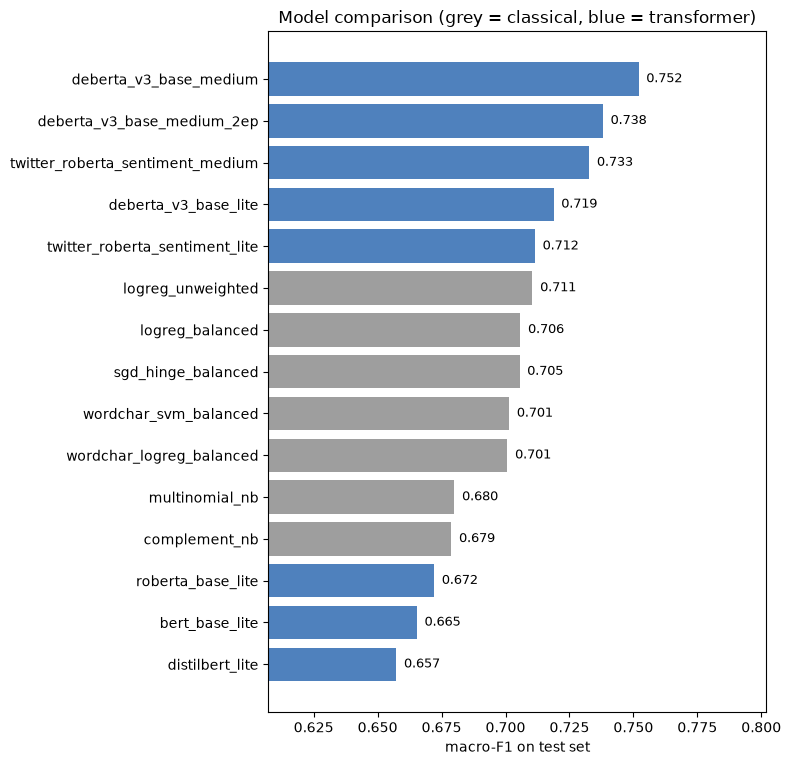

In [9]:
fig, ax = plt.subplots(figsize=(8, 0.45 * len(table) + 1))
colors = table['family'].map({'classical': '#9e9e9e', 'transformer': '#4f81bd'})
ax.barh(table.index[::-1], table['macro_f1'][::-1], color=colors[::-1])
for i, v in enumerate(table['macro_f1'][::-1]): ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('macro-F1 on test set'); ax.set_xlim(table['macro_f1'].min() - 0.05, min(1, table['macro_f1'].max() + 0.05))
ax.set_title('Model comparison (grey = classical, blue = transformer)')
plt.tight_layout(); plt.savefig(OUTPUT / 'model_comparison.png', dpi=120); plt.show()

In [10]:
top = table.iloc[0]
close = table[table['macro_f1'] >= top['macro_f1'] - 0.01]
winner = close.sort_values(['recall_neutral', 'macro_f1'], ascending=False).index[0]
print(f'Best model: {winner}  (macro-F1 {table.loc[winner, "macro_f1"]:.3f}, neutral recall {table.loc[winner, "recall_neutral"]:.3f})')
json.dump({'best_model': winner, **table.loc[winner].to_dict()}, open(OUTPUT / 'best_model.json', 'w'), indent=2, default=str)
table.round(3).to_csv(OUTPUT / 'model_comparison.csv')

Best model: deberta_v3_base_medium  (macro-F1 0.752, neutral recall 0.641)
